# Lab 10: K-Nearest Neighbors & Evaluation Metrics
### Iris Dataset Classification


## Step 1: Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

## Task 1: Data Preprocessing
### 1a. Load the Iris dataset using read_csv() and display first few rows

In [4]:
# Load dataset using read_csv() as required (NOT sklearn.datasets)
# The iris.csv file should have columns: sepal_length, sepal_width, petal_length, petal_width, species
df = pd.read_csv('Iris.csv')

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

First 5 rows of dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset shape: (150, 6)

Column names: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


### 1b. Check for missing values

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

# If there are missing values, drop them
df = df.dropna()
print("\nDataset after handling missing values:", df.shape)

Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Dataset after handling missing values: (150, 6)


### 1c. Prepare features and labels, encode species if needed

In [10]:
# Separate features (X) and target labels (y)
# The iris.csv 'species' column contains text like 'Iris-setosa' — encode to numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = df['Species'].values

target_names = le.classes_
print("Classes:", target_names)

Classes: [0 1 2]


### 1d. Split into 80% training and 20% testing

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 120
Testing samples:  30


### 1e. Standardize features using StandardScaler

In [12]:
# fit_transform on training data, transform only on test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features standardized successfully.")
print(f"Mean of training features (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Std  of training features (should be ~1): {X_train_scaled.std(axis=0).round(4)}")

Features standardized successfully.
Mean of training features (should be ~0): [ 0. -0. -0. -0.]
Std  of training features (should be ~1): [1. 1. 1. 1.]


---
## Task 2: Train KNN Model & Experiment with Different K Values

In [13]:
k_values = [3, 5, 7]

print("Accuracy for different values of K:")
print("-" * 30)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"K = {k}  -->  Accuracy = {acc * 100:.2f}%")

Accuracy for different values of K:
------------------------------
K = 3  -->  Accuracy = 100.00%
K = 5  -->  Accuracy = 100.00%
K = 7  -->  Accuracy = 100.00%


---
## Task 3: Model Evaluation (using K=5)
Compute Accuracy, Precision, Recall, F1-Score, and Confusion Matrix

In [14]:
# Train final model with K=5 (default)
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X_train_scaled, y_train)
y_pred_5 = knn_5.predict(X_test_scaled)

# ---- Without sklearn (manual formulas) ----
cm = confusion_matrix(y_test, y_pred_5)

# For binary confusion matrix: TP, TN, FP, FN
# For multiclass we use sklearn metrics with average='macro'

# ---- With sklearn ----
accuracy  = accuracy_score(y_test, y_pred_5)
precision = precision_score(y_test, y_pred_5, average='macro')
recall    = recall_score(y_test, y_pred_5, average='macro')
f1        = f1_score(y_test, y_pred_5, average='macro')

print("=" * 40)
print("KNN (K=5) — Model Evaluation Results")
print("=" * 40)
print(f"Accuracy  : {accuracy  * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall    * 100:.2f}%")
print(f"F1-Score  : {f1        * 100:.2f}%")
print("\nConfusion Matrix:")
print(cm)

KNN (K=5) — Model Evaluation Results
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1-Score  : 100.00%

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


---
## Task 4: Visualization — Confusion Matrix Plot

<Figure size 700x500 with 0 Axes>

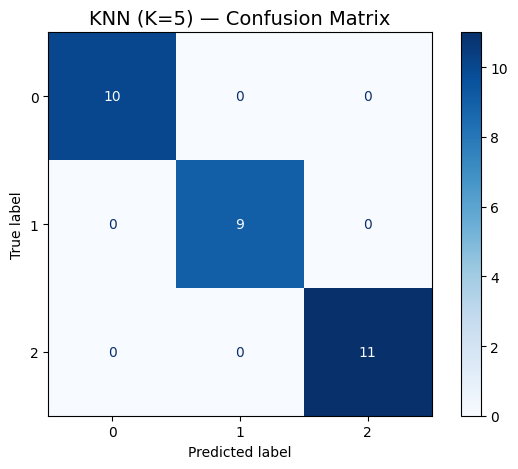

In [15]:
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_5,
    display_labels=target_names,
    cmap='Blues'
)
plt.title("KNN (K=5) — Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

---
## Bonus: Manual Metric Formulas (without sklearn)
For binary classification demonstration

In [16]:
# Manual formulas as taught in the lab (binary example using class 0 vs rest)
# Binarize for class 0 (Setosa) for demonstration
y_test_bin = (y_test == 0).astype(int)
y_pred_bin = (y_pred_5 == 0).astype(int)

TP = ((y_test_bin == 1) & (y_pred_bin == 1)).sum()
TN = ((y_test_bin == 0) & (y_pred_bin == 0)).sum()
FP = ((y_test_bin == 0) & (y_pred_bin == 1)).sum()
FN = ((y_test_bin == 1) & (y_pred_bin == 0)).sum()

# Manual formulas from the lab PDF
accuracy_manual  = (TP + TN) / (TP + FP + TN + FN)
recall_manual    = TP / (TP + FN)  if (TP + FN) > 0 else 0
precision_manual = TP / (TP + FP) if (TP + FP) > 0 else 0
f1_manual        = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual) \
                   if (precision_manual + recall_manual) > 0 else 0

print("Manual Formulas (Class: Setosa vs Rest)")
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"Accuracy  (manual): {accuracy_manual  * 100:.2f}%")
print(f"Recall    (manual): {recall_manual    * 100:.2f}%")
print(f"Precision (manual): {precision_manual * 100:.2f}%")
print(f"F1-Score  (manual): {f1_manual        * 100:.2f}%")

Manual Formulas (Class: Setosa vs Rest)
TP=10, TN=20, FP=0, FN=0
Accuracy  (manual): 100.00%
Recall    (manual): 100.00%
Precision (manual): 100.00%
F1-Score  (manual): 100.00%
